# Qt-Ft Agglomeration Simulation

This notebook runs ReaDDy2-based simulations of Qt-Ft nanoparticle agglomeration.

**Structure:** all code lives in the `qtft` package
- `qtft.config` / `qtft.system` / `qtft.engine` — configuration + simulation
- `qtft.analysis` — analysis (matplotlib-free); `qtft.plotting` — plotting
- `qtft.ensemble` — `EnsembleSimulation` for multi-replica runs

## 1. Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import readdy
import sys

# Import the qtft package
import qtft as sim
import qtft.analysis as analysis
import qtft.plotting as plotting
from qtft import EnsembleSimulation

print(f"ReaDDy: {readdy.__version__}")
print(f"Python: {sys.version}")

ReaDDy: 2.0.13-5
Python: 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:29:10) [GCC 14.3.0]


## 2. Module Reload Helper

In [2]:
import importlib
import qtft, qtft.config, qtft.system, qtft.engine, qtft.analysis, qtft.plotting, qtft.ensemble

# Reload submodules in dependency order (restart the kernel for deep changes).
for _m in (qtft.config, qtft.system, qtft.engine, qtft.analysis,
           qtft.plotting, qtft.ensemble, qtft):
    importlib.reload(_m)

sim = qtft
analysis = qtft.analysis
plotting = qtft.plotting
from qtft import EnsembleSimulation
print("Modules reloaded")

Modules reloaded


## 3. Configuration

In [ ]:
# ============================================================
# SIMULATION CONFIGURATION
# ============================================================
# Modify parameters here and re-run this cell

# ----- Output options -----
SAVE_PLOTS = False   # set True to write single-run plot SVGs to disk

config = sim.SimulationConfig(
    # ----- Particle properties -----
    qt=sim.ParticleConfig(
        name="Qt",
        radius=42.0,             # nm (Encapsulin)
        diffusion=0.5,           # nm^2/ns
        cluster_diffusion=0.5,   # nm^2/ns
    ),
    ft=sim.ParticleConfig(
        name="Ft",
        radius=12.0,             # nm (Ferritin)
        diffusion=1.0,           # nm^2/ns
        cluster_diffusion=1.0,   # nm^2/ns
    ),
    
    # ----- Topology/binding parameters -----
    topology=sim.TopologyConfig(
        name="QtFt_Cluster",
        binding_radius=55.0,     # nm (r_Qt + r_Ft = 40 + 12 + buffer)
        kon=0.001,               # nm^3/(ns*particles) (binding rate)
        k_bond=10.0,             # kJ/(mol*nm^2) (bond stiffness)
    ),
    
    # ----- Lennard-Jones parameters -----
    # Per-pair epsilon values (kJ/mol). Cluster and mixed-state values
    # cascade from free-free values by default if not specified.
    # Set any epsilon to 0 to disable that interaction entirely.
    lj=sim.LennardJonesConfig(
        epsilon_QtQt=2.5,        # kJ/mol - Qt-Qt interaction (~4 kT)
        epsilon_FtFt=1.5,        # kJ/mol - Ft-Ft interaction
        epsilon_QtFt=2.5,        # kJ/mol - Qt-Ft interaction
        epsilon_QtCQtC=None,   # defaults to epsilon_QtQt
        epsilon_FtCFtC=None,   # defaults to epsilon_FtFt
        epsilon_QtCFtC=None,   # defaults to epsilon_QtFt (set to 0 to disable)
        potential_type="LJ",    # "WCA" (purely repulsive) or "LJ" (with attraction)
    ),
    
    # ----- Simulation box -----
    box_size=(1000, 1000, 1000),  # nm (larger box for larger particles)
    periodic_boundary=True,
    temperature=300.0,             # Kelvin
    
    # ----- Integration -----
    timestep=3e-2,              # ns (1.0 ps)
    n_steps=5000,              # Total steps  # before 5  000 000
    
    # ----- Recording -----
    record_stride=100,              # Save trajectory every N steps
    observable_stride=100,          # Record observables every N steps
    particles_observable_stride=1000,  # Enables faster analysis (10x coarser than trajectory)
                                       # Set to None to disable and save disk space
    
    # ----- Particles -----
    n_qt=200,                  # Number of Qt particles
    n_ft=400,                      # Number of Ft particles
    
    # ----- Execution -----
    kernel="CPU",
    n_threads=3,
    rng_seed=22,
    
    # ----- Output -----
    # output_file is auto-generated from parameters, e.g.:
    # qt_ft_200Qt_400Ft_WCA_eQQ7_eFF7_eQF7_kon175_dt10ps_59us.h5
    # Uncomment to override: output_file="custom_name.h5",
)

# Print configuration summary
config.print_summary()

## 4. Run Simulation

In [5]:
# Equilibration
pos_qt, pos_ft = sim.equilibrate_system(config, n_steps=5000)

# Production
system = sim.create_system(config)
simulation = sim.create_simulation(system, config, overwrite=True)
sim.place_particles(simulation, config, positions_qt=pos_qt, positions_ft=pos_ft)
trajectory = sim.run_simulation(simulation, config)

# Summary
analysis.print_analysis_summary(config.output_file, config)


EQUILIBRATION
  Running 5,000 steps without reactions (WCA potential)

✓ Species: Qt, Ft, QtC, FtC
✓ WCA potentials (10 registered): ε_QQ=2.5, ε_FF=1.5, ε_QF=2.5
✓ Topology 'QtFt_Cluster': bonds configured, reactions DISABLED (equilibration mode)
✓ System created: 1000×1000×1000 nm box (equilibration mode - no reactions)
✓ Placed 200 Qt + 400 Ft particles (random)
  Running equilibration...
Configured kernel context with:
--------------------------------
 - kBT = 2.4361377615198827
 - periodic b.c. = (true, true, true)
 - box size = (1000, 1000, 1000)
 - particle types:
     * Topology particle type "FtC" with D=1
     * Topology particle type "QtC" with D=0.5
     * Topology particle type "Ft" with D=1
     * Topology particle type "Qt" with D=0.5
 - potentials of order 2:
     * for types "QtC" and "Ft"
         * 12-6-Lennard-Jones potential with cutoff=60.612948, epsilon=2.5, k=10, and with energy shift
     * for types "Qt" and "QtC"
         * 12-6-Lennard-Jones potential with c

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:02<00:00, 178.57it/s]


[2026-06-13 19:48:13] [info] Simulation completed

EQUILIBRATION COMPLETE
  Retrieved 200 Qt + 400 Ft positions

✓ Species: Qt, Ft, QtC, FtC
✓ LJ potentials (10 registered): ε_QQ=2.5, ε_FF=1.5, ε_QF=2.5
✓ Topology 'QtFt_Cluster': binding_radius=55.0 nm, kon=0.001, k_bond=10.0
✓ System created: 1000×1000×1000 nm box
✓ Observables registered (stride=100, forces/virial stride=10000, particles observable stride=1000)
✓ Simulation created: CPU kernel, 3 threads
✓ Placed 200 Qt (provided) + 400 Ft (provided) particles

RUNNING SIMULATION
  Particles: 200 Qt + 400 Ft
  Duration: 0.1 µs (5,000 steps)

Configured kernel context with:
--------------------------------
 - kBT = 2.4361377615198827
 - periodic b.c. = (true, true, true)
 - box size = (1000, 1000, 1000)
 - particle types:
     * Topology particle type "FtC" with D=1
     * Topology particle type "QtC" with D=0.5
     * Topology particle type "Ft" with D=1
     * Topology particle type "Qt" with D=0.5
 - potentials of order 2:
     * f

100%|██████████| 500/500 [00:23<00:00, 21.20it/s]


[2026-06-13 19:48:37] [info] Simulation completed

SIMULATION COMPLETE

  Bond counting: Method 1 (topology.edges) - exact count

SIMULATION RESULTS SUMMARY

Initial state (t=0):
  Topologies: 600
  Average size: 1.00 particles
  Largest: 1 particles
  Bonds: 0

Final state (t=0.15 µs):
  Topologies: 599
  Average size: 1.00 particles
  Largest: 2 particles
  Bonds: 1

Final size distribution:
  Median: 1.0
  Mean: 1.0
  Std: 0.0
  Range: 1 - 2

Particle distribution:
  Monomers (1): 598 particles (99.7%)
  Small (2-12): 2 particles (0.3%)
  Medium (13-60): 0 particles (0.0%)
  Large (61-150): 0 particles (0.0%)
  Very large (>150): 0 particles (0.0%)



In [ ]:
# Plot observables
print("\nGenerating observable plots...")
data = plotting.plot_observables(config.output_file, config, save_path="plots_observables.svg" if SAVE_PLOTS else None)

# Plot cluster analysis
print("\nGenerating cluster analysis plots...")
cluster_stats = plotting.plot_cluster_analysis(config.output_file, config=config, save_path="plots_clusters.svg" if SAVE_PLOTS else None)

## 5. Export for Visualization

In [20]:
# Derive xyz filename from the h5 output filename
xyz_file = config.output_file.replace(".h5", ".xyz")
xyz_path = analysis.convert_h5_to_xyz(config.output_file, xyz_file, config, overwrite=True)

✓ Exported OVITO-friendly XYZ to qt_ft_agglomeration.xyz


## 6. Structural Cluster Analysis

In [ ]:
structural_data = plotting.plot_structural_cluster_analysis(
    config.output_file,
    config,
    save_path="plots_structural_analysis.svg" if SAVE_PLOTS else None,
    stride=1,
    min_cluster_size_morphology=3,
    min_cluster_size_spatial=2,
)

## 7. Cluster Composition Analysis

In [ ]:
composition_data = plotting.plot_cluster_composition(
    config.output_file,
    config,
    save_path="plots_cluster_composition.svg" if SAVE_PLOTS else None,
    stride=1,
    min_cluster_size=2,
)

## 8. Save Configuration

In [16]:
config.save_json('simulation_config.json')
# To load: config = sim.SimulationConfig.load_json('simulation_config.json')

✓ Configuration saved to simulation_config.json


## 9. Ensemble Simulations

In [23]:
# ============================================================
# CREATE ENSEMBLE
# ============================================================
# The folder name is auto-generated from simulation parameters:
#   {name}_{n_qt}Qt_{n_ft}Ft_dt{timestep}ps_{total_time}us
#
# Examples:
#   - name=None:       200Qt_400Ft_dt10ps_30us/
#   - name="highFt":   highFt_200Qt_400Ft_dt10ps_30us/

ensemble = EnsembleSimulation(
    base_config=config,
    n_replicas=10,
    name=None,           # Optional: descriptive name prefix (e.g., "test", "highFt")
    base_dir="Different_Particle_Ratios",        # Base directory for output (folder created as subdirectory)
)

print(f"Seeds: {ensemble.seeds}")

✓ Ensemble created: 200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us
  Output directory: Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/
  Replicas: 10
Seeds: [1950464737, 2539317803, 3333880692, 2150020773, 2633213151, 1529125172, 4010032112, 3532649711, 2858885004, 2799241814]


In [ ]:
# ============================================================
# Option A: Run locally
# ============================================================
# After completion, automatically:
#   - Collects results from all replicas
#   - Computes statistics
#   - Saves JSON/NPZ files for plotting

ensemble.run_local(
    parallel=True,           # Run replicas in parallel
    n_workers=10,             # Number of parallel workers
    overwrite=True,          # Overwrite existing output directory
    equilibration_steps=5000,
    
    
)

✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_000.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_001.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_002.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_003.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_004.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_005.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_006.json
✓ Configuration saved to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ

✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_002.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_005.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_004.json


✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_001.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_003.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_008.json✓ Configuration loaded from Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon1e-05_dt30ps_150us/configs/config_000.json✓ Configuration loaded from Different_Particle_Ratio

 98%|█████████▊| 491/500 [00:21<00:00, 22.34it/s]

100%|█████████▉| 498/500 [00:21<00:00, 22.09it/s]

EQUILIBRATION COMPLETE
  Retrieved 200 Qt + 400 Ft positions



...


SIMULATION COMPLETE



 99%|█████████▉| 493989/500000 [12:02:32<05:06, 19.60it/s]

[2026-03-27 00:04:40] [info] Simulation completed


100%|██████████| 500000/500000 [12:07:42<00:00, 11.45it/s]



SIMULATION COMPLETE

[2026-03-27 00:09:49] [info] Simulation completed
  Completed: 1/10 (replica 0)
  Completed: 2/10 (replica 1)
  Completed: 3/10 (replica 2)
  Completed: 4/10 (replica 3)
  Completed: 5/10 (replica 4)
  Completed: 6/10 (replica 5)
  Completed: 7/10 (replica 6)
  Completed: 8/10 (replica 7)
  Completed: 9/10 (replica 8)
  Completed: 10/10 (replica 9)

ALL REPLICAS COMPLETED

POST-PROCESSING

COLLECTING ENSEMBLE RESULTS
  Replica 0: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 1: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 2: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 3: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 4: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 5: Loading...
  Bond counting: Method 1 (topology.edges) - exact count
  Replica 6: Loading...
  Bond counting: Method 1 (topology.edges) - ex

In [ ]:
# ============================================================
# Option B: Generate SLURM scripts for cluster execution
# ============================================================

# ----- SLURM script for running replica simulations -----
ensemble.generate_slurm_scripts(
    # --- SLURM job settings ---
    partition="cm4_tiny",        # (required, str) SLURM partition name
    cluster="cm4",               # (optional, str) SLURM cluster name, None to omit
    qos="cm4_tiny",              # (optional, str) Quality of service, None to omit
    time="08:00:00",             # (optional, str) Wall time limit per replica (HH:MM:SS)
    cpus_per_task=12,            # (optional, int) CPUs per replica
    memory="32G",                # (optional, str) Memory per replica
    
    # --- Conda environment ---
    conda_base="<YOUR_CONDA_PATH>",  # (required, str) Full path to conda installation, e.g. "/home/user/miniconda3"
    conda_env="readdy",              # (optional, str) Name of conda environment with ReaDDy
    
    # --- Paths ---
    scripts_dir="~/Readdy_Simulations",  # (optional, str) Directory where Python scripts are located
    
    # --- Email notifications ---
    mail_user=None,              # (optional, str) Email for notifications, e.g. "user@example.com"
    mail_type="ALL",             # (optional, str) When to send emails: NONE, BEGIN, END, FAIL, ALL
)

# ----- SLURM script for post-simulation analysis -----
ensemble.generate_analysis_slurm_script(
    # --- SLURM job settings ---
    partition="cm4_tiny",        # (required, str) SLURM partition name
    cluster="cm4",               # (optional, str) SLURM cluster name, None to omit
    qos="cm4_tiny",              # (optional, str) Quality of service, None to omit
    time="04:00:00",             # (optional, str) Wall time limit (HH:MM:SS)
    cpus_per_task=4,             # (optional, int) CPUs for parallel analysis
    memory="32G",                # (optional, str) Memory allocation
    
    # --- Conda environment ---
    conda_base="<YOUR_CONDA_PATH>",  # (required, str) Full path to conda installation, e.g. "/home/user/miniconda3"
    conda_env="readdy",              # (optional, str) Name of conda environment with ReaDDy
    
    # --- Paths and analysis settings ---
    scripts_dir="~/Readdy_Simulations",  # (optional, str) Directory where Python scripts are located
    stride=10,                           # (optional, int) Analyze every Nth frame for structural analysis
    
    # --- Email notifications ---
    mail_user=None,              # (optional, str) Email for notifications, e.g. "user@example.com"
    mail_type="ALL",             # (optional, str) When to send emails: NONE, BEGIN, END, FAIL, ALL
)

In [4]:
# Analyze results
ensemble.collect_results(require_all=False)
ensemble.compute_statistics()
ensemble.print_summary()

NameError: name 'ensemble' is not defined


Generating ensemble observable plots...
✓ Saved plot to ensemble_observables.svg


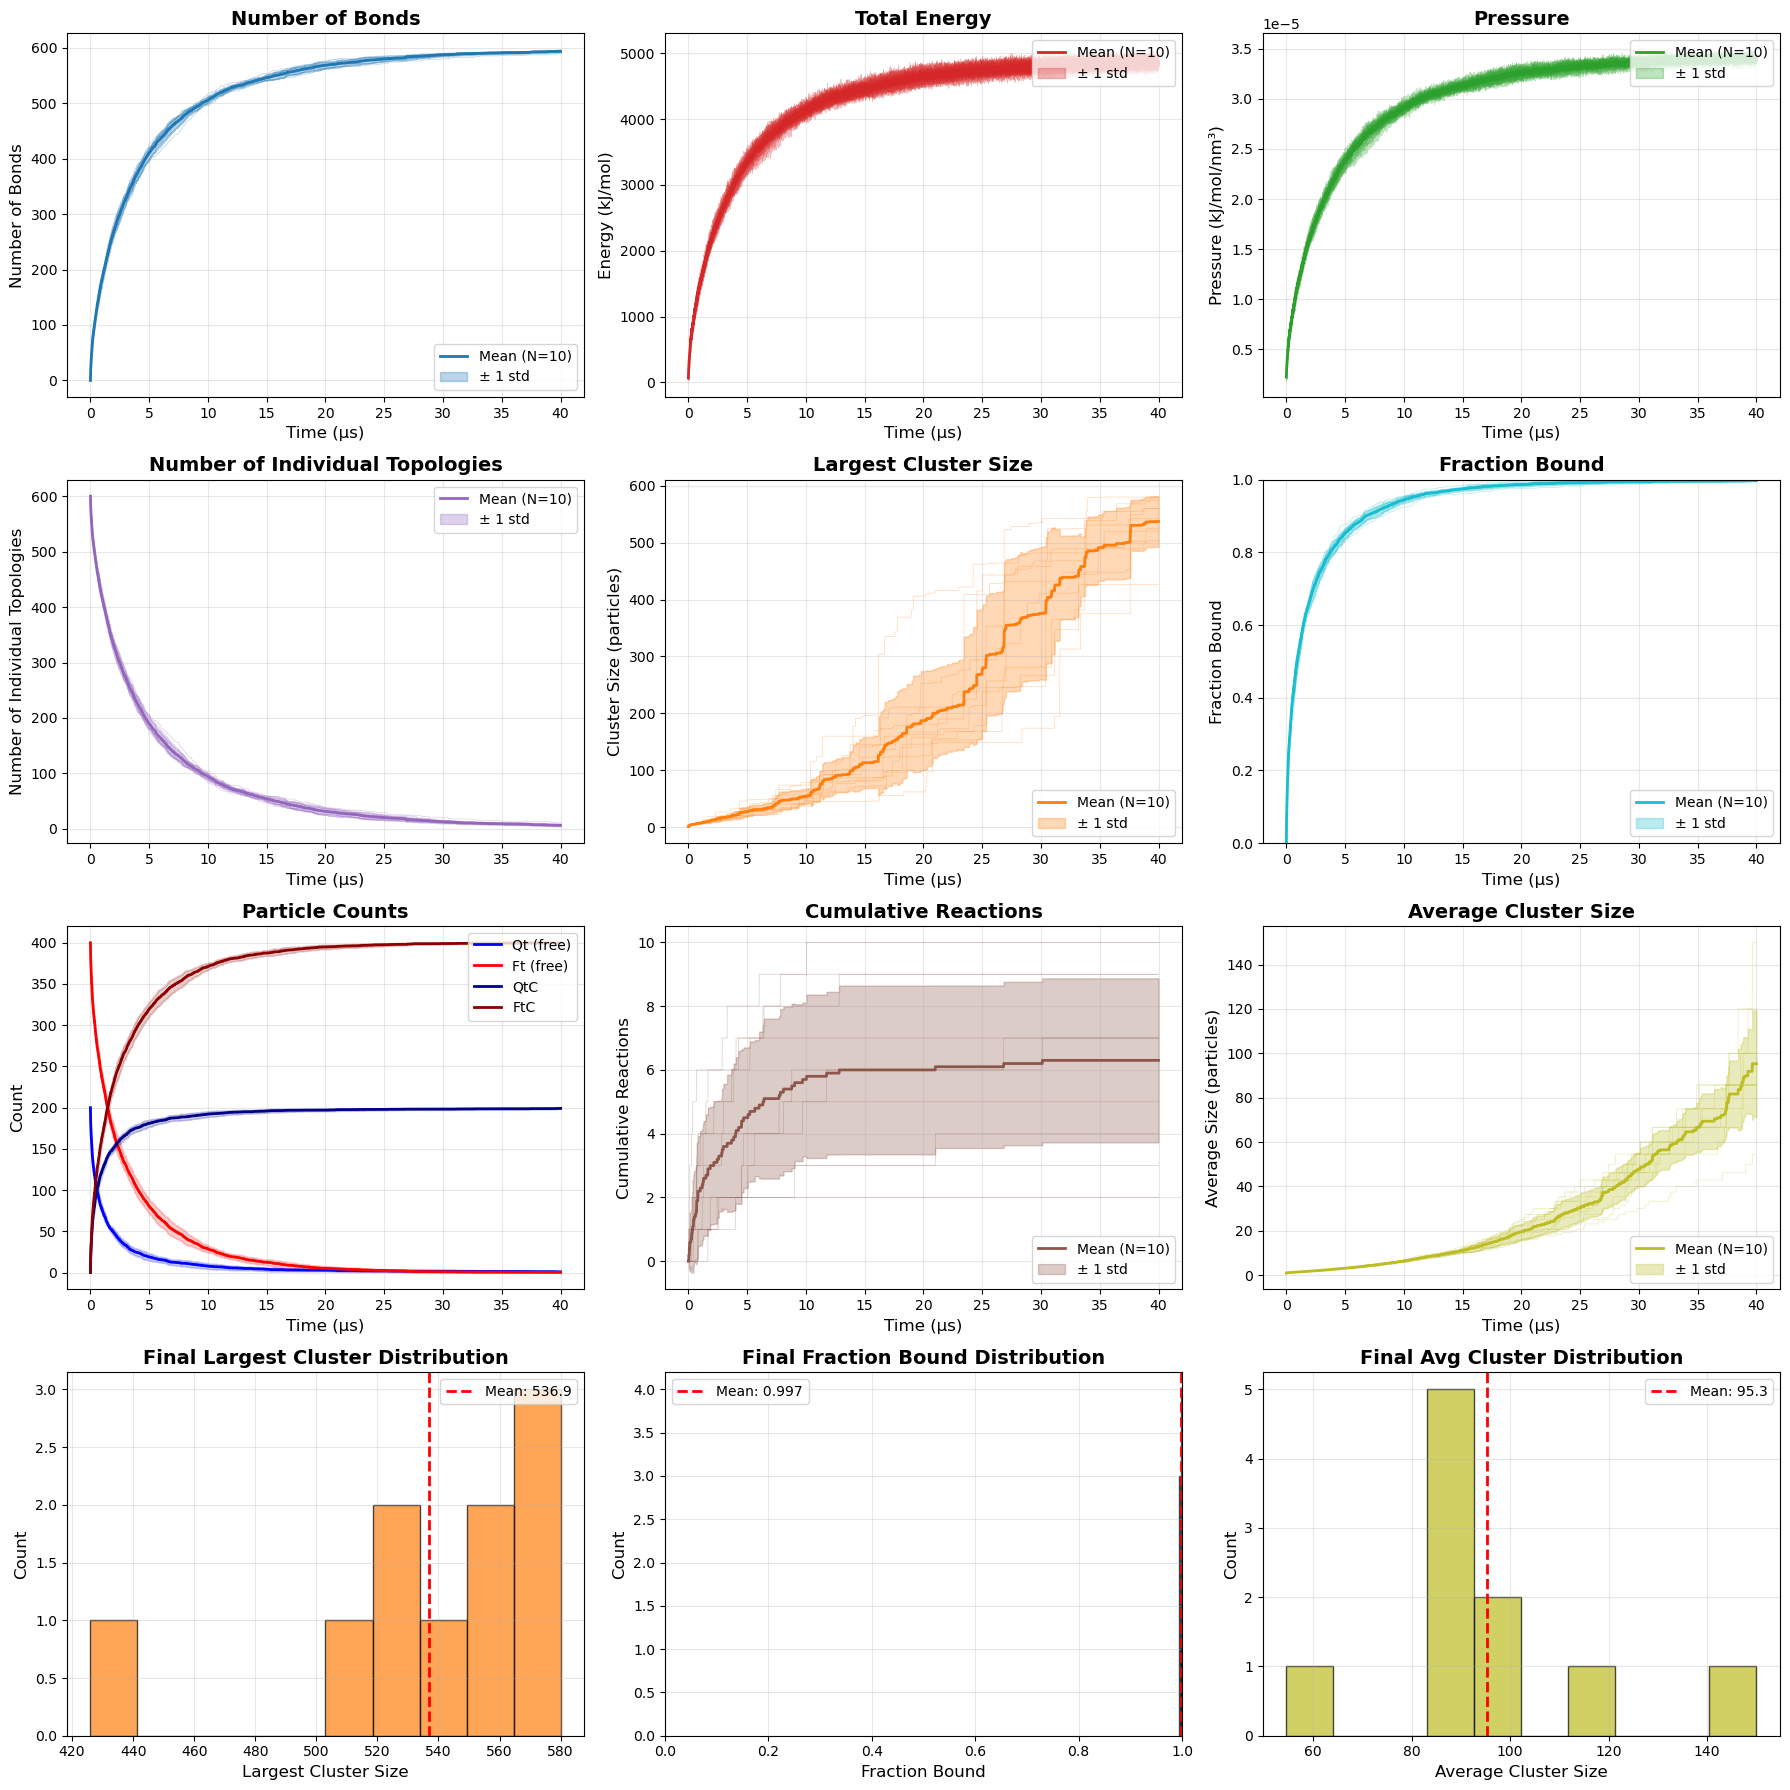

In [31]:
stats, structural, config_dict = ensemble.to_plotting_format()
fig = plotting.plot_ensemble_observables(
    stats, config_dict, structural,
    show_individual=True, save_path="ensemble_observables.svg",
)


COMPUTING ADVANCED STATISTICS
Using stride=10 (analyzing every 10th frame)

  Replica 0 (1/10):
    ✓ Frame data: 401 frames extracted


  Morphology: 100%|██████████| 401/401 [00:02<00:00, 143.86frame/s]


    ✓ Morphology


  Spatial: 100%|██████████| 401/401 [00:08<00:00, 44.93frame/s] 


    ✓ Spatial


...

    ✓ Spatial


  Contacts: 100%|██████████| 401/401 [00:00<00:00, 2726.55frame/s]


    ✓ Contacts


  Composition: 100%|██████████| 401/401 [00:00<00:00, 2312.88frame/s]


    ✓ Composition

Processing advanced data...
✓ Advanced statistics computed

Generating advanced ensemble plots...
✓ Saved plot to ensemble_advanced.svg


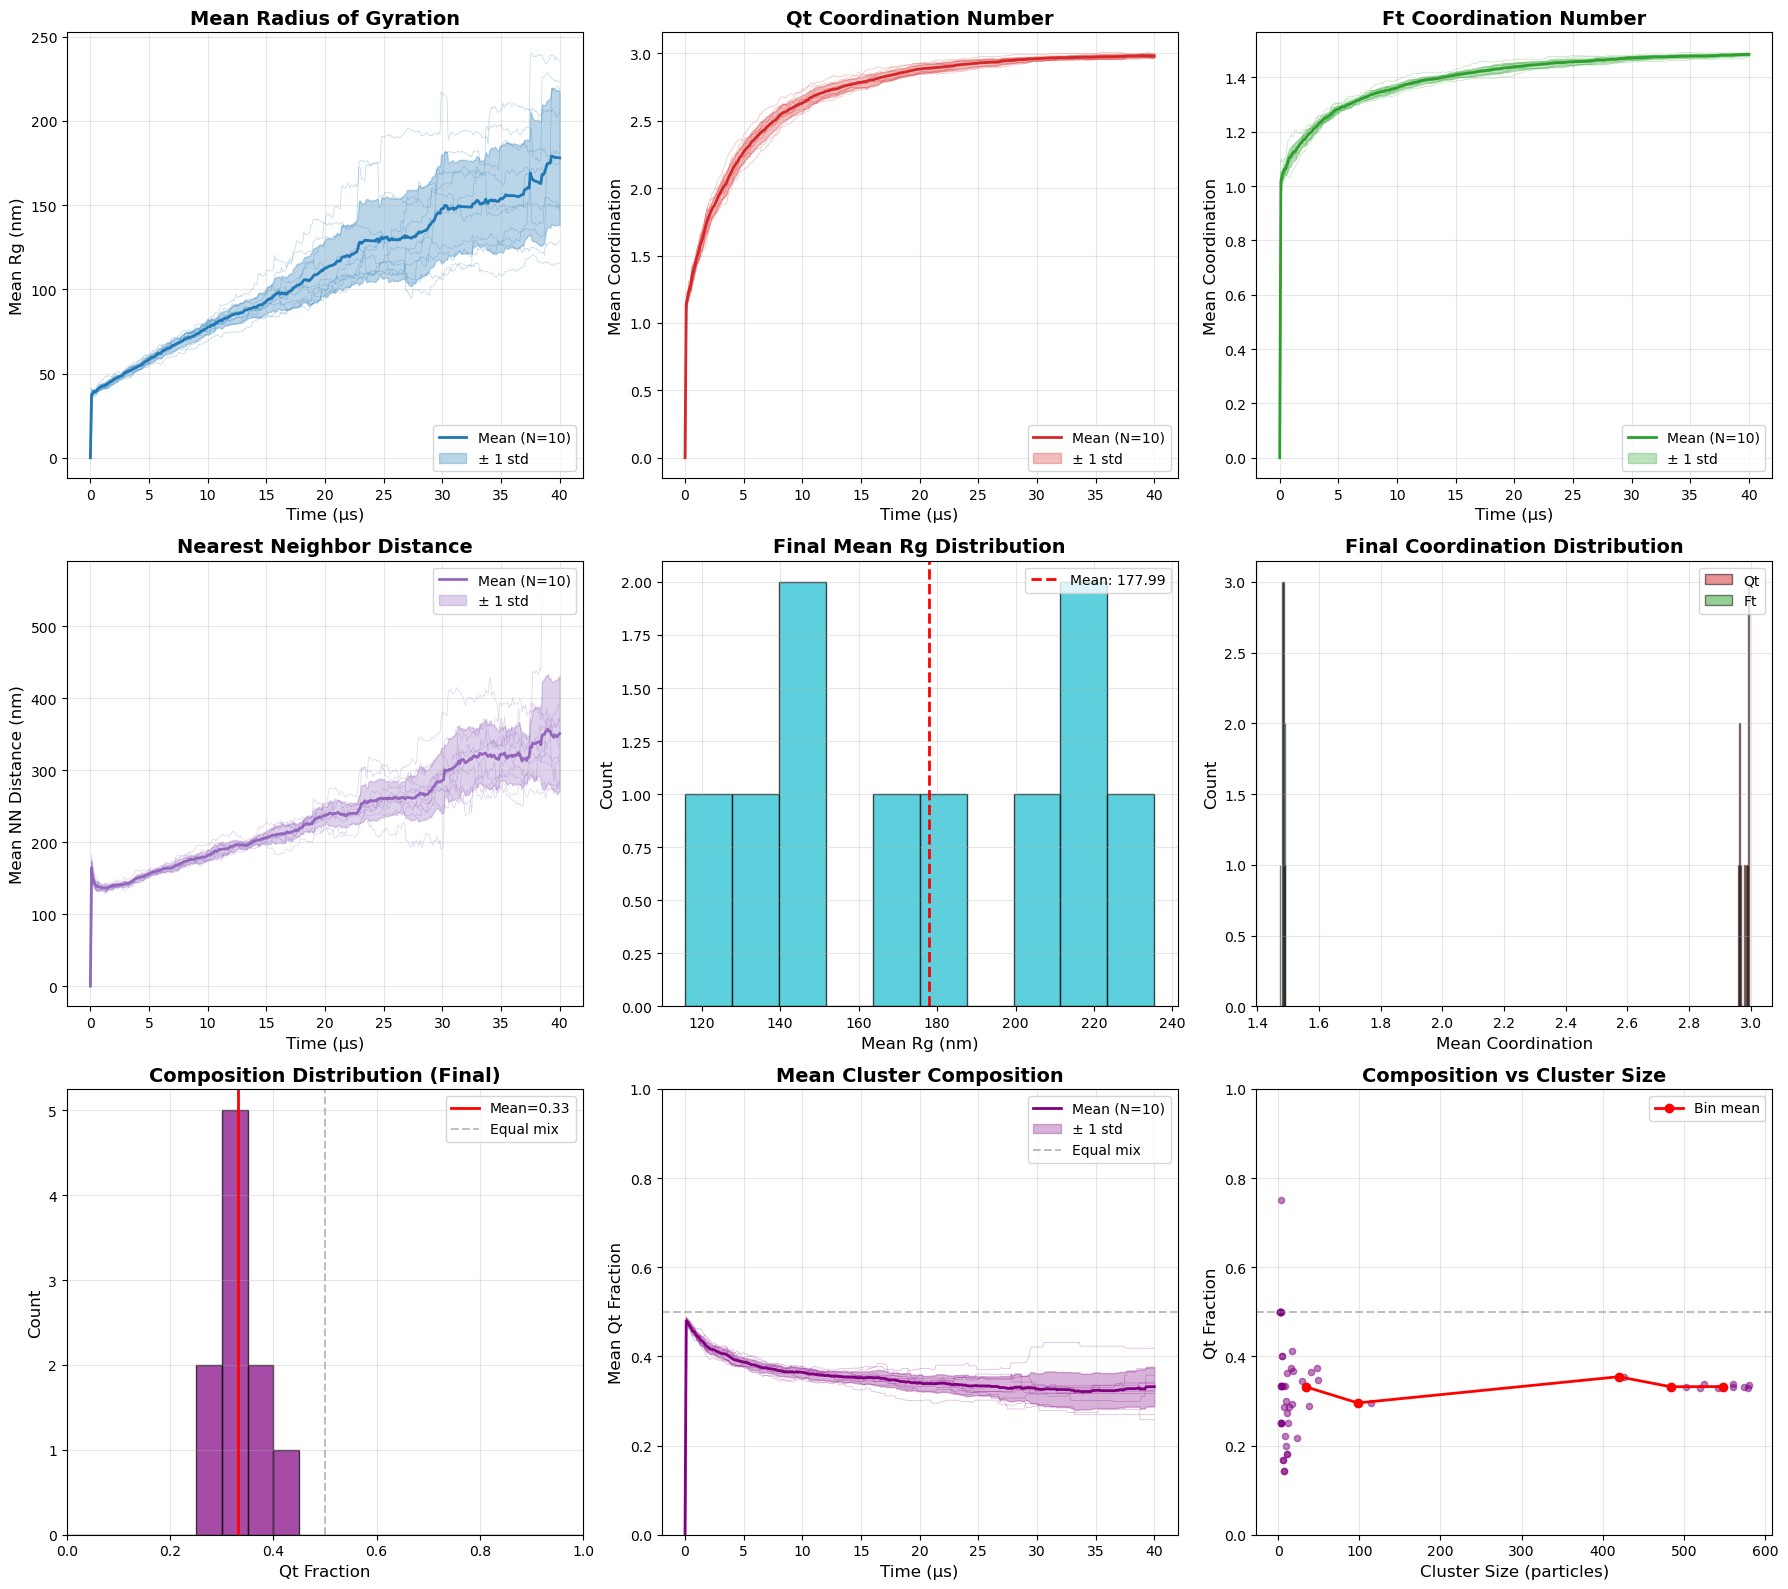

In [32]:
# Structural ensemble analysis
# Structural analysis is now computed automatically by run_local()
stats, structural, config_dict = ensemble.to_plotting_format()
fig = plotting.plot_ensemble_structural(
    stats, structural, config_dict,
    show_individual=True, save_path="ensemble_structural.svg",
)

## 10. Export Trajectory to XYZ (for OVITO)

In [21]:
# ============================================================
# EXPORT ENSEMBLE TRAJECTORY TO XYZ FOR OVITO VISUALIZATION
# ============================================================

# To reload an ensemble later (update path to match your ensemble folder):
ensemble = EnsembleSimulation.load("Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon0.001_dt30ps_150us")

# Select which replica to export (0 = first replica)
REPLICA_TO_EXPORT = 0

# Get the replica's config and trajectory path
replica_config = ensemble.replica_configs[REPLICA_TO_EXPORT]
h5_file = replica_config.output_file

# Output XYZ file in the same directory as the H5 file
import os
h5_dir = os.path.dirname(h5_file)
xyz_file = os.path.join(h5_dir, "trajectory.xyz")

print(f"Converting replica {REPLICA_TO_EXPORT}:")
print(f"  Input:  {h5_file}")
print(f"  Output: {xyz_file}")
print()

# Convert to XYZ
analysis.convert_h5_to_xyz(h5_file, xyz_file, replica_config, overwrite=True)

print(f"\nFile size: {os.path.getsize(xyz_file) / (1024*1024):.1f} MB")
print("\nOpen in OVITO: File -> Load File -> select the .xyz file")

✓ Loaded ensemble from Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon0.001_dt30ps_150us/ensemble_state.json
Converting replica 0:
  Input:  Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon0.001_dt30ps_150us/replica_000/trajectory.h5
  Output: Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon0.001_dt30ps_150us/replica_000/trajectory.xyz

✓ Exported OVITO-friendly XYZ to Different_Particle_Ratios/200Qt_400Ft_LJ_eQQ2.5_eFF1.5_eQF2.5_kon0.001_dt30ps_150us/replica_000/trajectory.xyz

File size: 1221.1 MB

Open in OVITO: File -> Load File -> select the .xyz file


In [ ]:
# ============================================================
# EXPORT MULTIPLE REPLICAS (optional)
# ============================================================
# Uncomment and run to export all replicas

# for i, replica_config in enumerate(ensemble.replica_configs):
#     h5_file = replica_config.output_file
#     if not os.path.exists(h5_file):
#         print(f"Replica {i}: SKIPPED (H5 file not found)")
#         continue
#     
#     h5_dir = os.path.dirname(h5_file)
#     xyz_file = os.path.join(h5_dir, "trajectory.xyz")
#     
#     print(f"Replica {i}: Converting...")
#     analysis.convert_h5_to_xyz(h5_file, xyz_file, replica_config, overwrite=True)
#     print(f"  -> {xyz_file} ({os.path.getsize(xyz_file) / (1024*1024):.1f} MB)")